In [21]:
import json, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import confusion_matrix

PLOTS_DIR = "plots"
RNG_SEED = 42
DATA_DIR = "data"

if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)

np.random.seed(RNG_SEED)

In [22]:
def save_plot(fig, filename):
    fig_file_path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(fig_file_path, dpi=300)

In [23]:
# labels are converted to integers to be able to use `np.bincount`
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv", header=None).to_numpy()
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv", header=None).to_numpy().ravel().astype(int)
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv",  header=None).to_numpy()
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv",  header=None).to_numpy().ravel().astype(int)

print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test ", X_test.shape)
print("y_test ", y_test.shape)

labels = np.unique(y_train)
assert np.array_equal(labels, np.unique(y_test)), "Train and test labels do not match!"
print("Labels:", labels)

X_train (33724, 16)
y_train (33724,)
X_test  (13901, 16)
y_test  (13901,)
Labels: [0 1 2 3 4]


# 3.1 Data understanding and preprocessing

In [24]:
counts_train = np.bincount(y_train)
freq_train = counts_train / counts_train.sum()
print("Class frequencies:", freq_train)

Class frequencies: [0.52087534 0.09551062 0.25272803 0.04693986 0.08394615]


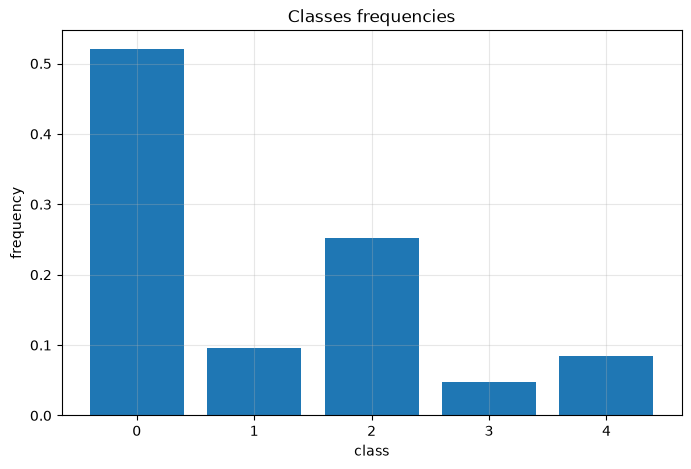

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(r"Classes frequencies")
ax.set_xlabel(r"class")
ax.set_ylabel(r"frequency")
ax.grid(alpha=0.3)
ax.bar(labels, freq_train)
plt.show()
save_plot(fig, "classes_freqs.png")